In [1]:
import os
import sys
parent_dir = os.path.abspath('..')
sys.path.append(parent_dir) #set root to path so src visible

# Import des librairies
!pip install catboost xgboost lightgbm catboost scikit-learn matplotlib pandas

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor

In [2]:
df_portefeuille = data_loading("training")

In [8]:
# On accède au premier objet du tuple, puis aux colonnes
print(df_portefeuille[0].columns.tolist())

['client_code', 'client_age_souscripteur', 'client_sexe_souscripteur', 'client_ro_souscripteur', 'client_code_postal', 'client_departement', 'client_departement_avant_changement_12_mois', 'client_a_conjoint', 'client_nb_enfants', 'client_structure_familiale', 'client_nb_assures_contrat', 'client_a_garantie_prevoyance', 'client_produit', 'client_garantie_base', 'client_garantie_base_plus_options', 'client_millesime_tarifaire_produit', 'client_zone_tarifaire', 'client_type_zone_tarifaire', 'client_est_contrat_madelin', 'client_date_debut_effet_garantie', 'client_anciennete_contrat_annees', 'client_cotisations_annualisees_n_moins2', 'client_cotisations_annualisees_n_moins1', 'client_cotisations_annualisees_n', 'client_cotisations_annualisees_n_plus1', 'client_mode_paiement', 'client_frequence_paiement', 'client_nom_banque', 'client_nps_date_reponse_n', 'client_nps_note_reco_n', 'client_nps_verbatim_n', 'client_nps_date_reponse_n_moins1', 'client_nps_note_reco_n_moins1', 'client_nps_verbat

In [15]:
df = df_portefeuille[0]
# Liste des colonnes cibles
colonnes_nps = [
    'client_nps_date_reponse_n', 
    'client_nps_note_reco_n', 
    'client_nps_verbatim_n', 
    'client_nps_date_reponse_n_moins1', 
    'client_nps_note_reco_n_moins1', 
    'client_nps_verbatim_n_moins1',
    'target_resiliation_6mois'

]

# Extraction dans un nouveau DataFrame
df_nps = df[colonnes_nps]

# Afficher les premières lignes pour vérifier
print(df_nps.head())

  client_nps_date_reponse_n  client_nps_note_reco_n client_nps_verbatim_n  \
0                       NaN                     NaN                   NaN   
1                       NaN                     NaN                   NaN   
2                       NaN                     NaN                   NaN   
3                       NaN                     NaN                   NaN   
4                       NaN                     NaN                   NaN   

  client_nps_date_reponse_n_moins1  client_nps_note_reco_n_moins1  \
0                              NaN                            NaN   
1                              NaN                            NaN   
2                              NaN                            NaN   
3                              NaN                            NaN   
4                              NaN                            NaN   

  client_nps_verbatim_n_moins1  target_resiliation_6mois  
0                          NaN                         0  
1   

In [16]:
df_nps.isna().sum()

client_nps_date_reponse_n           125100
client_nps_note_reco_n              125100
client_nps_verbatim_n               126629
client_nps_date_reponse_n_moins1    127060
client_nps_note_reco_n_moins1       127060
client_nps_verbatim_n_moins1        128204
target_resiliation_6mois                 0
dtype: int64

In [34]:
!pip install pandas wordcloud matplotlib textblob transformers torch vaderSentiment-fr

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 35.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 26.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 32.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 39.4 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 45.7 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 49.3 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 49.1 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 49.0 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 56.1 MB/s  0:00:03m0:00:0100:01
   ━━━━━

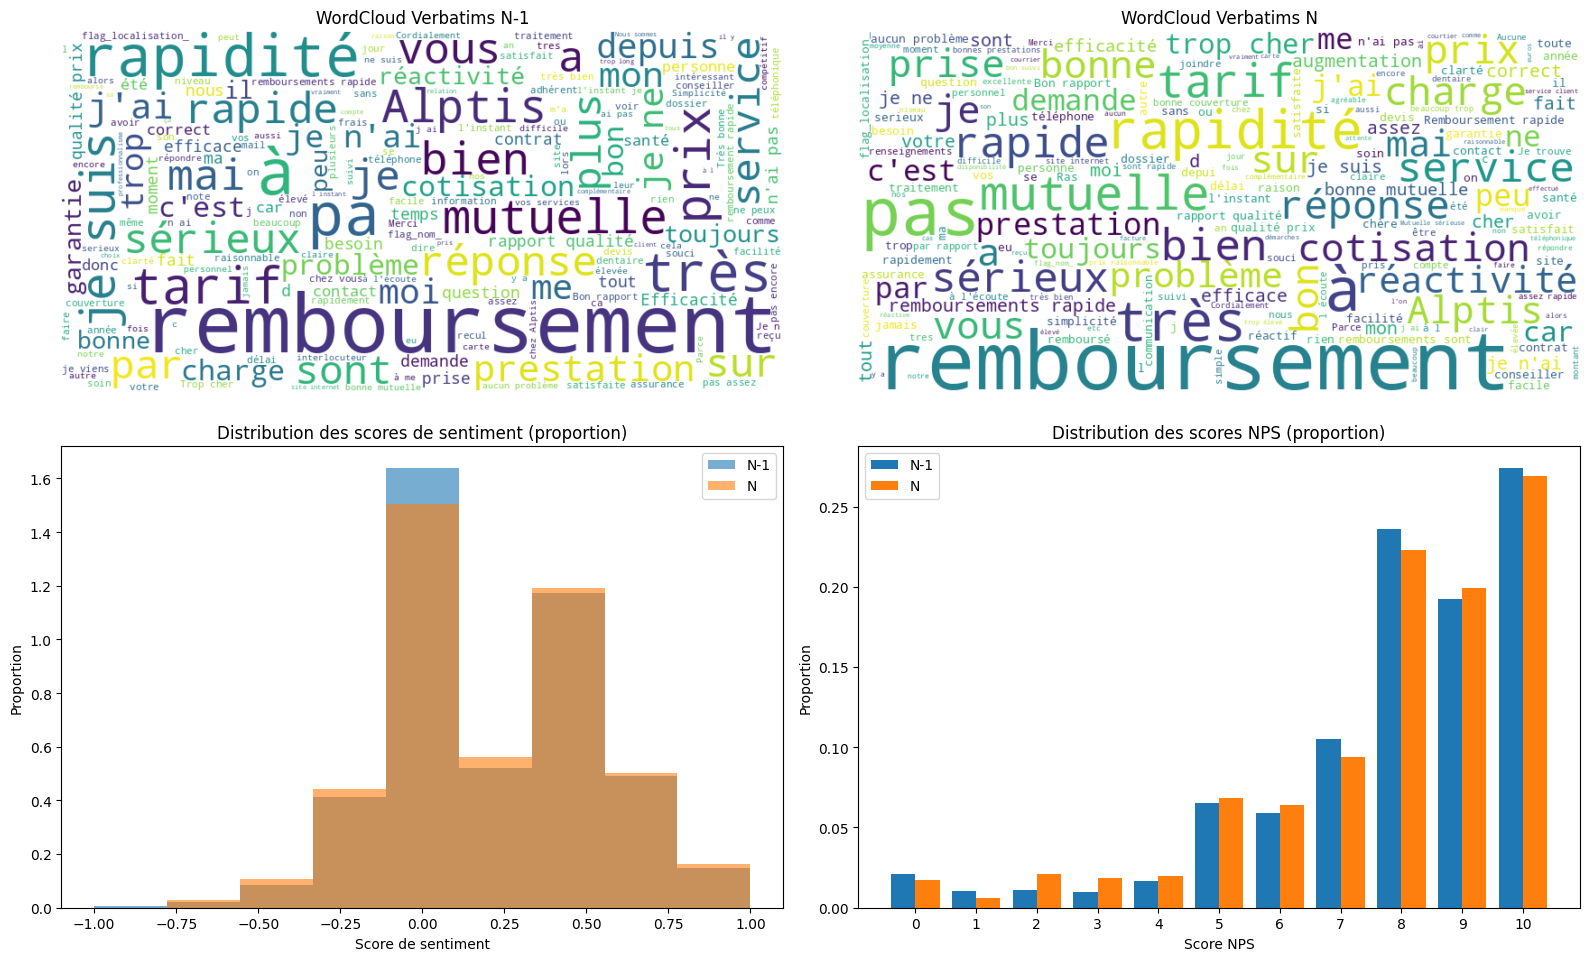

Note moyenne N-1 : 7.90
Note moyenne N   : 7.83

Répartition sentiments N-1 :
sentiment_label_n1
Positif    612
Neutre     402
Négatif    139
Name: count, dtype: int64

Répartition sentiments N :
sentiment_label_n
Positif    629
Neutre     371
Négatif    153
Name: count, dtype: int64


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer

df_nps = df.dropna(subset=['client_nps_verbatim_n', 'client_nps_verbatim_n_moins1']).copy()


analyzer = SentimentIntensityAnalyzer()

def calculer_sentiment(texte):
    return analyzer.polarity_scores(str(texte))["compound"]

def sentiment_label(score):
    if score > 0.1:
        return "Positif"
    elif score < -0.1:
        return "Négatif"
    else:
        return "Neutre"

df_nps["sentiment_score_n"] = df_nps["client_nps_verbatim_n"].apply(calculer_sentiment)
df_nps["sentiment_score_n1"] = df_nps["client_nps_verbatim_n_moins1"].apply(calculer_sentiment)

df_nps["sentiment_label_n"] = df_nps["sentiment_score_n"].apply(sentiment_label)
df_nps["sentiment_label_n1"] = df_nps["sentiment_score_n1"].apply(sentiment_label)

texte_n = " ".join(df_nps["client_nps_verbatim_n"].astype(str))
texte_n1 = " ".join(df_nps["client_nps_verbatim_n_moins1"].astype(str))

stop_words = set([
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'dans',
    'pour', 'que', 'qui', 'au', 'aux', 'avec', 'ce', 'cette', 'ces', 'est'
])

wordcloud_n = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n)

wordcloud_n1 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n1)

mean_n = df_nps["client_nps_note_reco_n"].mean()
mean_n1 = df_nps["client_nps_note_reco_n_moins1"].mean()

sent_n = df_nps["sentiment_label_n"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)
sent_n1 = df_nps["sentiment_label_n1"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(wordcloud_n1, interpolation="bilinear")
axes[0, 0].axis("off")
axes[0, 0].set_title("WordCloud Verbatims N-1")

axes[0, 1].imshow(wordcloud_n, interpolation="bilinear")
axes[0, 1].axis("off")
axes[0, 1].set_title("WordCloud Verbatims N")

bins = np.linspace(-1, 1, 10)

axes[1, 0].hist(
    df_nps["sentiment_score_n1"],
    bins=bins,
    alpha=0.6,
    label="N-1",
    density=True
)

axes[1, 0].hist(
    df_nps["sentiment_score_n"],
    bins=bins,
    alpha=0.6,
    label="N",
    density=True
)

axes[1, 0].set_title("Distribution des scores de sentiment (proportion)")
axes[1, 0].set_xlabel("Score de sentiment")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend()

bins = np.arange(0, 12) - 0.5

counts_n1, _ = np.histogram(df_nps["client_nps_note_reco_n_moins1"], bins=bins)
counts_n, _ = np.histogram(df_nps["client_nps_note_reco_n"], bins=bins)

prop_n1 = counts_n1 / counts_n1.sum()
prop_n = counts_n / counts_n.sum()

x = np.arange(0, 11)
axes[1, 1].bar(x - 0.2, prop_n1, width=0.4, label="N-1")
axes[1, 1].bar(x + 0.2, prop_n, width=0.4, label="N")
axes[1, 1].set_xticks(x)
axes[1, 1].set_title("Distribution des scores NPS (proportion)")
axes[1, 1].set_xlabel("Score NPS")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

print(f"Note moyenne N-1 : {mean_n1:.2f}")
print(f"Note moyenne N   : {mean_n:.2f}")

print("\nRépartition sentiments N-1 :")
print(sent_n1)

print("\nRépartition sentiments N :")
print(sent_n)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nlptown/bert-base-multilingual-uncased-sentiment/8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6730.01it/s]
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment "HTTP/1.1 200 OK"


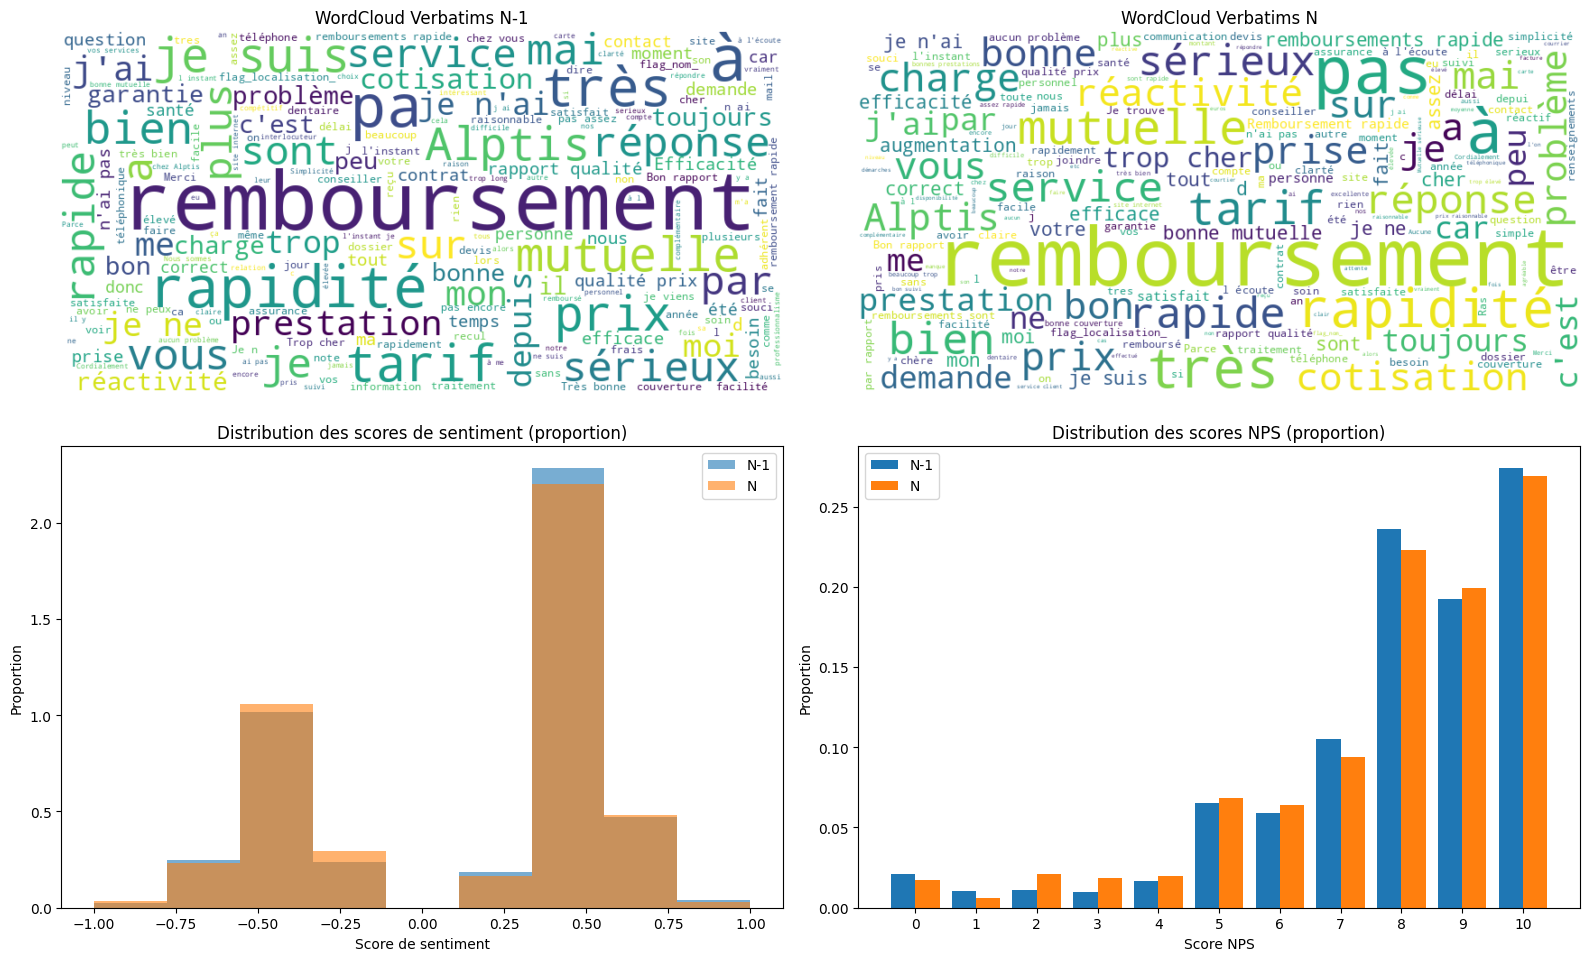

Note moyenne N-1 : 7.90
Note moyenne N   : 7.83

Répartition sentiments N-1 :
sentiment_label_n1
Positif    763
Neutre       0
Négatif    390
Name: count, dtype: int64

Répartition sentiments N :
sentiment_label_n
Positif    737
Neutre       0
Négatif    416
Name: count, dtype: int64


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline



df_nps = df.dropna(subset=['client_nps_verbatim_n', 'client_nps_verbatim_n_moins1']).copy()

sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

def sentiment_transformer(text):
    result = sentiment_model(str(text))[0]
    return result["score"] if result["label"] in ["4 stars", "5 stars"] else -result["score"]


def sentiment_label(score):
    if score > 0.1:
        return "Positif"
    elif score < -0.1:
        return "Négatif"
    else:
        return "Neutre"

df_nps["sentiment_score_n"] = df_nps["client_nps_verbatim_n"].apply(sentiment_transformer)
df_nps["sentiment_score_n1"] = df_nps["client_nps_verbatim_n_moins1"].apply(sentiment_transformer)

df_nps["sentiment_label_n"] = df_nps["sentiment_score_n"].apply(sentiment_label)
df_nps["sentiment_label_n1"] = df_nps["sentiment_score_n1"].apply(sentiment_label)

texte_n = " ".join(df_nps["client_nps_verbatim_n"].astype(str))
texte_n1 = " ".join(df_nps["client_nps_verbatim_n_moins1"].astype(str))

stop_words = set([
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'dans',
    'pour', 'que', 'qui', 'au', 'aux', 'avec', 'ce', 'cette', 'ces', 'est'
])

wordcloud_n = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n)

wordcloud_n1 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n1)

mean_n = df_nps["client_nps_note_reco_n"].mean()
mean_n1 = df_nps["client_nps_note_reco_n_moins1"].mean()

sent_n = df_nps["sentiment_label_n"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)
sent_n1 = df_nps["sentiment_label_n1"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(wordcloud_n1, interpolation="bilinear")
axes[0, 0].axis("off")
axes[0, 0].set_title("WordCloud Verbatims N-1")

axes[0, 1].imshow(wordcloud_n, interpolation="bilinear")
axes[0, 1].axis("off")
axes[0, 1].set_title("WordCloud Verbatims N")

bins = np.linspace(-1, 1, 10)

axes[1, 0].hist(
    df_nps["sentiment_score_n1"],
    bins=bins,
    alpha=0.6,
    label="N-1",
    density=True
)

axes[1, 0].hist(
    df_nps["sentiment_score_n"],
    bins=bins,
    alpha=0.6,
    label="N",
    density=True
)

axes[1, 0].set_title("Distribution des scores de sentiment (proportion)")
axes[1, 0].set_xlabel("Score de sentiment")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend()

bins = np.arange(0, 12) - 0.5

counts_n1, _ = np.histogram(df_nps["client_nps_note_reco_n_moins1"], bins=bins)
counts_n, _ = np.histogram(df_nps["client_nps_note_reco_n"], bins=bins)

prop_n1 = counts_n1 / counts_n1.sum()
prop_n = counts_n / counts_n.sum()

x = np.arange(0, 11)
axes[1, 1].bar(x - 0.2, prop_n1, width=0.4, label="N-1")
axes[1, 1].bar(x + 0.2, prop_n, width=0.4, label="N")
axes[1, 1].set_xticks(x)
axes[1, 1].set_title("Distribution des scores NPS (proportion)")
axes[1, 1].set_xlabel("Score NPS")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

print(f"Note moyenne N-1 : {mean_n1:.2f}")
print(f"Note moyenne N   : {mean_n:.2f}")

print("\nRépartition sentiments N-1 :")
print(sent_n1)

print("\nRépartition sentiments N :")
print(sent_n)